<a href="https://colab.research.google.com/github/Hemang2001/M.Tech_Project_Predictive_Maintenance_Railway_Domain/blob/main/Model1_Track_Defect_DS/Data_Preprocessing_steps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salmaneunus/railway-track-fault-detection")

print("Path to dataset files:", path)

100%|██████████| 2.00G/2.00G [00:22<00:00, 95.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/salmaneunus/railway-track-fault-detection/versions/2


In [ ]:
DATASET_PATH = "/root/.cache/kagglehub/datasets/salmaneunus/railway-track-fault-detection/versions/2"

#### Dataset Pre-processing

It Reads images from folders,
Applies preprocessing, and
Feeds data to model in batches

Basic steps using ImageDataGenerator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = DATASET_PATH + "/Railway Track fault Detection Updated/Train"
val_dir = DATASET_PATH + "/Railway Track fault Detection Updated/Validation"
test_dir = DATASET_PATH + "/Railway Track fault Detection Updated/Test"

# Normalize images
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,  #Resizes ALL images to the same size
    batch_size=BATCH_SIZE, #Instead of loading all images at once:Loads 32 images at a time
    class_mode='binary'    #Because 2 classes: Defective and Non defective
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
print(train_data.class_indices)

Found 299 images belonging to 2 classes.
Found 62 images belonging to 2 classes.
Found 22 images belonging to 2 classes.
{'Defective': 0, 'Non defective': 1}


Data Augmentation

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

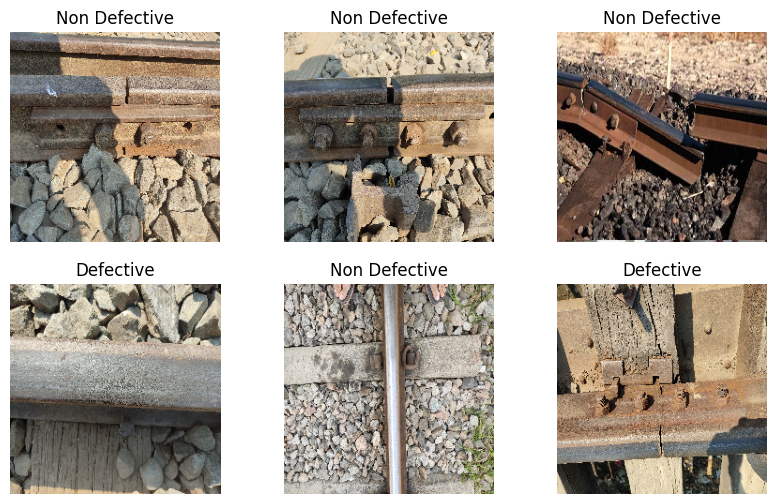

In [ ]:
images, labels = next(train_data)  # get one batch

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title("Defective" if labels[i]==1 else "Non Defective")
    plt.axis('off')

plt.show()

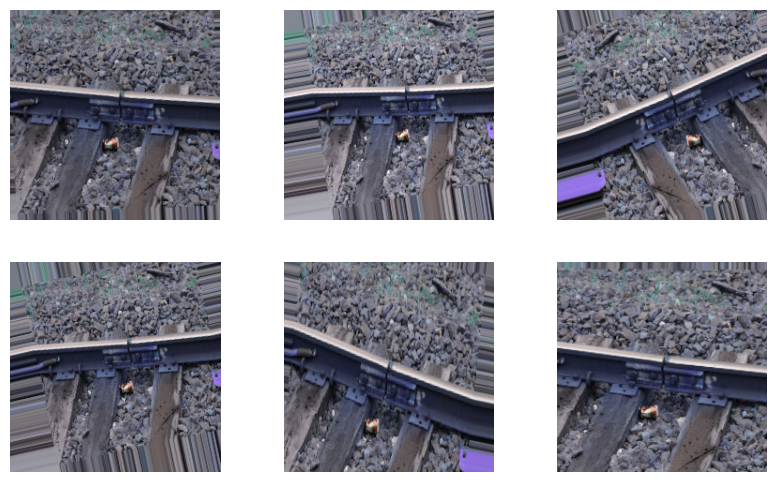

Image path: /root/.cache/kagglehub/datasets/salmaneunus/railway-track-fault-detection/versions/2/Railway Track fault Detection Updated/Train/Defective/E116_8996.jpg
Image loaded: True
(1, 224, 224, 3)


In [ ]:
#Load one single image and Visualise it's Augmented version
import os
import cv2
import numpy as np

# Pick one image
img_path = DATASET_PATH + "/Railway Track fault Detection Updated/Train/Defective/" + os.listdir(DATASET_PATH + "/Railway Track fault Detection Updated/Train/Defective")[2]

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
img = np.expand_dims(img, axis=0)

plt.figure(figsize=(10,6))

i = 1
for batch in train_gen.flow(img, batch_size=1):
    plt.subplot(2,3,i)
    plt.imshow(batch[0])
    plt.axis('off')
    i += 1
    if i > 6:
        break

plt.show()

print("Image path:", img_path)
print("Image loaded:", img is not None)
print(img.shape)


/root/.cache/kagglehub/datasets/salmaneunus/railway-track-fault-detection/versions/2/Railway Track fault Detection Updated/Train/Defective/E116_8996.jpg


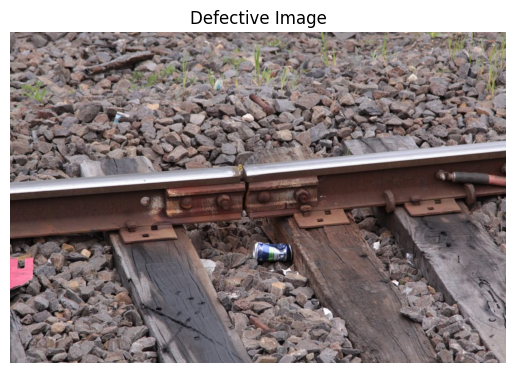

In [ ]:
#Load one single Image and Visualize it
img_path = DATASET_PATH + "/Railway Track fault Detection Updated/Train/Defective/" + os.listdir(DATASET_PATH + "/Railway Track fault Detection Updated/Train/Defective")[2]
print(img_path)


img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.title("Defective Image")
plt.show()

